In [ ]:
import discovery as ds
import jax
import discovery.samplers.numpyro as ds_numpyro
from matplotlib import pyplot as plt
import corner
import numpyro

In [46]:
psr = ds.Pulsar.read_feather("sim1.feather")

In [47]:
signals = [
    psr.residuals,                                                  # Data vector
    ds.makenoise_measurement_simple(psr),                           # White noise (EFAC/EQUAD)
    ds.makegp_timing(psr),                                          # Timing model
]

In [48]:
psl = ds.PulsarLikelihood(signals)

In [49]:
p0 = ds.sample_uniform(psl.logL.params)
print(p0)

{'SIM1_efac': 1.0218067044187267, 'SIM1_log10_t2equad': -8.337835220553288}


In [58]:
psl.logL(p0), jax.grad(psl.logL)(p0)

(Array(22017.6077556, dtype=float64),
 {'SIM1_efac': Array(7670.6116038, dtype=float64, weak_type=True),
  'SIM1_log10_t2equad': Array(0.61091047, dtype=float64, weak_type=True)})

In [ ]:
def model():
    # Priors
    a = numpyro.sample("a", dist.Uniform(0.1, 2.5))
    b = numpyro.sample("b", dist.Uniform(-9.0, -4.0))

    # Add log-likelihood
    numpyro.factor("log_likelihood", logL({"a": a, "b": b}))

{'SIM1_efac': Array(7670.6116038, dtype=float64, weak_type=True),
 'SIM1_log10_t2equad': Array(0.61091047, dtype=float64, weak_type=True)}

In [53]:
npmodel = ds_numpyro.makemodel_transformed(psl.logL)
npsampler = ds_numpyro.makesampler_nuts(npmodel)

In [54]:
npsampler.run(jax.random.PRNGKey(101))

  0%|          | 0/1536 [00:00<?, ?it/s]

sample: 100%|██████████| 1536/1536 [00:02<00:00, 716.32it/s, 7 steps of size 4.42e-01. acc. prob=0.91] 


In [55]:
chain = npsampler.to_df()

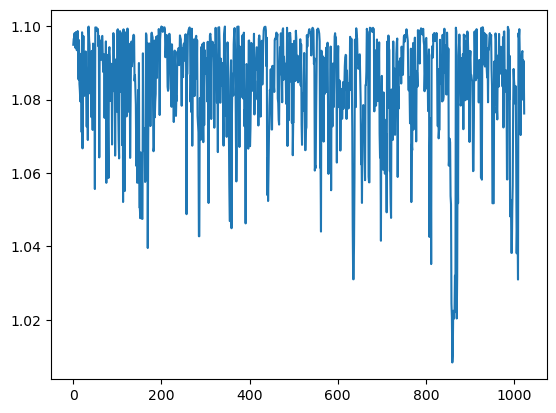

In [56]:
plt.plot(chain["SIM1_efac"].array)

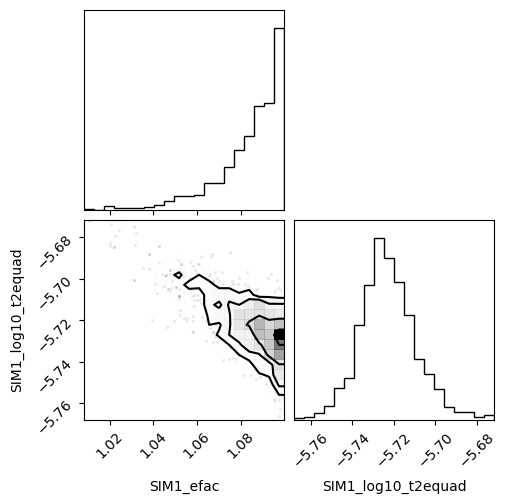

In [57]:
corner.corner(chain.to_numpy(), labels=psl.logL.params);